# Лабораторная работа №2. Эксперименты по настройке модели
**Лукожев Ильяс Хусенович, А-02м-25**

Цель — освоить пайплайны, генерацию и отбор признаков, настройку RandomForest
через Optuna и логирование в MLflow 2.16.0. Выполняются обязательные пункты.
Пункты 11, 13 и 15 со звёздочкой пропущены по выбору студента.

Перед выполнением запустите в отдельном терминале `sh mlflow/start_mlflow.sh`.
Критерий выбора победителя — средний F1 пяти стратифицированных CV-разбиений
обучающей части. Тестовые 25% не участвуют в подборе параметров.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "research" / "experiments.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display
from research.experiments import (
    load_data, configure_mlflow, make_pipeline, train_and_log, select_expert_columns,
    tune_best, comparison_plot, train_production, NUMERIC_FEATURES,
    CATEGORICAL_FEATURES, EXPERT_FEATURES, MODEL_NAME, ROOT,
)

client, experiment_id = configure_mlflow()
print("Эксперимент:", experiment_id)
print("MLflow UI: http://127.0.0.1:5000")

Эксперимент: 1
MLflow UI: http://127.0.0.1:5000


## 1. Загрузка очищенной выборки и разбиение 75% / 25%
Используется `data/clean_dataset.pkl` из ЛР1. Категории приводятся к строкам,
числовые признаки — к float64, чтобы будущий сервис принимал JSON.
Шесть пропусков были заполнены по всему исходному набору ещё в ЛР1.
Это наследуемое ограничение: при полноценном переобучении импутацию нужно
поместить в train-only pipeline. Все новые преобразования в ЛР2 обучаются
внутри train/CV. Для train_test_split заданы stratify=y и random_state=42.

In [2]:
X, y, X_train, X_test, y_train, y_test, dataset_hash = load_data()
print("Числовые признаки:", NUMERIC_FEATURES)
print("Категориальные признаки:", CATEGORICAL_FEATURES)
print("Цель: target (0 — нет заболевания, 1 — есть заболевание)")
print(f"Полная выборка: {len(X)}; train: {len(X_train)}; test: {len(X_test)}")
display(pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}))

Числовые признаки: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Категориальные признаки: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_group']
Цель: target (0 — нет заболевания, 1 — есть заболевание)
Полная выборка: 303; train: 227; test: 76


,train,test
target,,
0,123,41
1,104,35


## 2. Baseline: StandardScaler + TargetEncoder + RandomForest
`ColumnTransformer` масштабирует числовые признаки и кодирует категории через
`sklearn.preprocessing.TargetEncoder`. Его fit_transform использует внутренний
cross-fitting. Полный pipeline заново обучается в каждом CV-разбиении.
Baseline: 100 деревьев, стандартные параметры, random_state=42.
ROC-AUC считается по вероятностям класса 1. Модель, параметры, метрики,
сигнатура, пример входа, зависимости и списки столбцов логируются в MLflow
с flavour sklearn. Регистрируется первая версия модели.

In [3]:
results, fitted_models = [], {}
baseline_result, baseline_model, baseline_version = train_and_log(
    "baseline", X_train, y_train, X_test, y_test, dataset_hash,
    run_name="baseline", register=True,
)
results.append(baseline_result)
fitted_models["baseline"] = baseline_model
display(pd.DataFrame([baseline_result]))
display(baseline_model)
print("Версия baseline:", baseline_version)

2026/09/29 00:38:29 INFO mlflow.tracking._tracking_service.client: 🏃 View run baseline at: http://127.0.0.1:5000/#/experiments/1/runs/a197093fbc8c4b01bfd92ca5624cf840.


2026/09/29 00:38:29 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Successfully registered model 'HeartDiseaseClassifier'.


2026/09/29 00:38:29 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HeartDiseaseClassifier, version 1


Created version '1' of model 'HeartDiseaseClassifier'.


,name,kind,run_id,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
0,baseline,baseline,a197093fbc8c4b01bfd92ca5624cf840,0.815789,0.885714,0.849315,0.939721,0.767515,0.054245


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'ca']),
                                                 ('categorical',
                                                  TargetEncoder(random_state=42,
                                                                target_type='binary'),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'thal', 'age_group'])])),
                ('classification',
                 RandomForestClassifier(n_jobs=2, random_state=42))])

Версия baseline: 1


## 3. Feature extraction средствами sklearn
Для age, thalach, oldpeak добавляем PolynomialFeatures(degree=2) с последующим
StandardScaler. Временных признаков нет: для этих же трёх столбцов применяем
KBinsDiscretizer (4 квантильных интервала, ordinal) и масштабирование.
В итоге 14 исходных преобразованных + 9 polynomial + 3 bins = 26 столбцов.
Демонстрационный fit_transform не переиспользуется при оценке: каждый pipeline
обучает собственные преобразования. Имена всех 26 столбцов сохраняются в файл
и логируются вместе с моделью в features/transformed_columns.json.

In [4]:
X_train_fe_sklearn, engineered_names, selected_indices = select_expert_columns(X_train, y_train)
print("Размер X_train_fe_sklearn:", X_train_fe_sklearn.shape)
display(pd.DataFrame({"index": range(len(engineered_names)), "feature": engineered_names}))
engineered_result, engineered_model, _ = train_and_log(
    "engineered", X_train, y_train, X_test, y_test, dataset_hash,
    run_name="sklearn_features",
)
results.append(engineered_result)
fitted_models["sklearn_features"] = engineered_model
display(pd.DataFrame([engineered_result]))

Размер X_train_fe_sklearn: (227, 26)


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


,index,feature
0,0,numeric__age
1,1,numeric__trestbps
2,2,numeric__chol
3,3,numeric__thalach
4,4,numeric__oldpeak
5,5,numeric__ca
6,6,categorical__sex
7,7,categorical__cp
8,8,categorical__fbs
9,9,categorical__restecg


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


...

/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


2026/09/29 00:38:35 INFO mlflow.tracking._tracking_service.client: 🏃 View run sklearn_features at: http://127.0.0.1:5000/#/experiments/1/runs/3e24a542d68f466182e0f8ebba1071c4.


2026/09/29 00:38:35 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


,name,kind,run_id,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
0,sklearn_features,engineered,3e24a542d68f466182e0f8ebba1071c4,0.810811,0.857143,0.833333,0.918815,0.768583,0.048585


## 4. Feature selection: экспертный отбор 13 из 26 признаков
Выбор зафиксирован по EDA ЛР1 до просмотра результатов ЛР2: age, thalach,
oldpeak, ca; sex, cp, exang, slope, thal; два взаимодействия и два бина.
Убираем слабые по EDA chol, trestbps, fbs, restecg, линейные дубли, квадраты
и age_group. Взаимодействия позволяют проверить совместный эффект признаков.
Это учебная гипотеза: качество может как улучшиться, так и ухудшиться.
13 / 26 = 50% соответствует диапазону 20–70%. Между transform и classification
добавляем selection по индексам. Имена и индексы сохраняются отдельными файлами.

In [5]:
print("Выбранные имена:", EXPERT_FEATURES)
print("Выбранные индексы:", selected_indices)
selected_result, selected_model, _ = train_and_log(
    "expert_selected", X_train, y_train, X_test, y_test, dataset_hash,
    selected_indices=selected_indices, run_name="expert_selection",
)
results.append(selected_result)
fitted_models["expert_selection"] = selected_model
display(pd.DataFrame([selected_result]))

/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


Выбранные имена: ['numeric__age', 'numeric__thalach', 'numeric__oldpeak', 'numeric__ca', 'categorical__sex', 'categorical__cp', 'categorical__exang', 'categorical__slope', 'categorical__thal', 'polynomial__age thalach', 'polynomial__thalach oldpeak', 'bins__age', 'bins__thalach']
Выбранные индексы: [0, 3, 4, 5, 6, 7, 10, 11, 12, 18, 21, 23, 24]


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


2026/09/29 00:38:41 INFO mlflow.tracking._tracking_service.client: 🏃 View run expert_selection at: http://127.0.0.1:5000/#/experiments/1/runs/0cf92e5838c647e3b8d13ec5c968754d.


2026/09/29 00:38:41 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


,name,kind,run_id,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
0,expert_selection,expert_selected,0cf92e5838c647e3b8d13ec5c968754d,0.769231,0.857143,0.810811,0.929617,0.790922,0.071669


## 5. Optuna: максимизация F1, минимум 10 trials
Из трёх вариантов выбирается лучший по train CV F1. Тестовые метрики не
управляют поиском. Выполняем 12 trials с seed=42: n_estimators ∈ {50,100,150,200},
max_depth ∈ [3,12], max_features ∈ [0.1,1.0]. Явно указано direction="maximize".
Каждое испытание логируется отдельным вложенным run. После поиска модель
обучается на 227 строках, проверяется на 76 тестовых и регистрируется в реестре.

In [6]:
best_before_optuna = max(results, key=lambda result: result["cv_f1_mean"])
print("Лучший набор до Optuna:", best_before_optuna["name"])
study, best_cv_scores, search_run_id = tune_best(
    best_before_optuna["kind"], X_train, y_train, selected_indices, n_trials=12,
)
print("Выполнено trials:", len(study.trials))
print("Лучшее среднее CV F1:", study.best_value)
print("Параметры:", study.best_params)
display(study.trials_dataframe())

Лучший набор до Optuna: expert_selection


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


...

2026/09/29 00:39:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


2026/09/29 00:39:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run optuna_search at: http://127.0.0.1:5000/#/experiments/1/runs/da58bbf345b04358a629f00c6f3450de.


2026/09/29 00:39:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Выполнено trials: 12
Лучшее среднее CV F1: 0.7878651842323217
Параметры: {'n_estimators': 150, 'max_depth': 3, 'max_features': 0.9729188669457949}


,number,value,datetime_start,datetime_complete,duration,params_max_depth,params_max_features,params_n_estimators,state
0,0,0.768935,2026-09-29 00:38:41.928463,2026-09-29 00:38:46.194607,0 days 00:00:04.266144,12,0.758795,100,COMPLETE
1,1,0.775128,2026-09-29 00:38:46.194923,2026-09-29 00:38:51.654355,0 days 00:00:05.459432,4,0.240395,150,COMPLETE
2,2,0.767286,2026-09-29 00:38:51.655020,2026-09-29 00:38:54.312745,0 days 00:00:02.657725,11,0.641004,50,COMPLETE
3,3,0.787865,2026-09-29 00:38:54.313167,2026-09-29 00:39:00.257014,0 days 00:00:05.943847,3,0.972919,150,COMPLETE
4,4,0.786154,2026-09-29 00:39:00.257360,2026-09-29 00:39:07.207500,0 days 00:00:06.950140,5,0.263642,200,COMPLETE
5,5,0.777909,2026-09-29 00:39:07.207702,2026-09-29 00:39:09.476840,0 days 00:00:02.269138,6,0.572281,50,COMPLETE
6,6,0.775275,2026-09-29 00:39:09.477190,2026-09-29 00:39:12.846055,0 days 00:00:03.368865,5,0.650668,100,COMPLETE
7,7,0.785918,2026-09-29 00:39:12.846363,2026-09-29 00:39:15.094126,0 days 00:00:02.247763,5,0.429726,50,COMPLETE
8,8,0.785656,2026-09-29 00:39:15.094557,2026-09-29 00:39:18.023277,0 days 00:00:02.928720,10,0.279706,100,COMPLETE
9,9,0.760513,2026-09-29 00:39:18.023503,2026-09-29 00:39:22.104255,0 days 00:00:04.080752,8,0.141805,150,COMPLETE


In [7]:
tuned_result, tuned_model, tuned_version = train_and_log(
    best_before_optuna["kind"], X_train, y_train, X_test, y_test, dataset_hash,
    selected_indices=selected_indices, params=study.best_params, run_name="optuna_best",
    cv_scores=best_cv_scores, register=True,
)
results.append(tuned_result)
fitted_models["optuna_best"] = tuned_model
display(pd.DataFrame([tuned_result]))
print("Зарегистрированная версия:", tuned_version)

/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


2026/09/29 00:39:40 INFO mlflow.tracking._tracking_service.client: 🏃 View run optuna_best at: http://127.0.0.1:5000/#/experiments/1/runs/fa1ba3f094a04d4b9ca1c534e11805d5.


2026/09/29 00:39:40 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Registered model 'HeartDiseaseClassifier' already exists. Creating a new version of this model...
2026/09/29 00:39:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HeartDiseaseClassifier, version 2


Created version '2' of model 'HeartDiseaseClassifier'.


,name,kind,run_id,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
0,optuna_best,expert_selected,fa1ba3f094a04d4b9ca1c534e11805d5,0.789474,0.857143,0.821918,0.90453,0.787865,0.05744


Зарегистрированная версия: 2


## 6. Сравнение всех моделей
Таблица содержит обязательные тестовые precision, recall, F1 и ROC-AUC,
средний train CV F1 и его стандартное отклонение. Если Optuna уступает
исходному варианту, победителем остаётся конфигурация с более высоким CV F1.

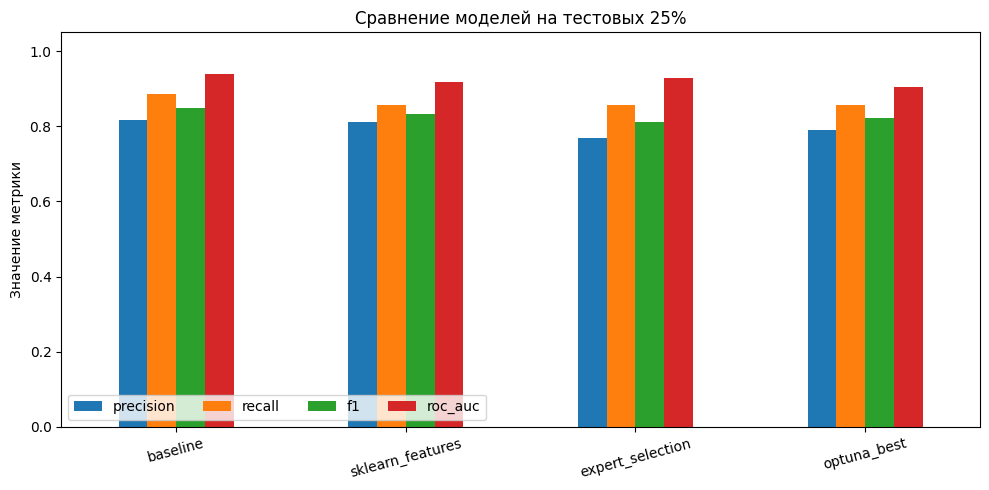

,name,kind,run_id,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
0,baseline,baseline,a197093fbc8c4b01bfd92ca5624cf840,0.815789,0.885714,0.849315,0.939721,0.767515,0.054245
1,sklearn_features,engineered,3e24a542d68f466182e0f8ebba1071c4,0.810811,0.857143,0.833333,0.918815,0.768583,0.048585
2,expert_selection,expert_selected,0cf92e5838c647e3b8d13ec5c968754d,0.769231,0.857143,0.810811,0.929617,0.790922,0.071669
3,optuna_best,expert_selected,fa1ba3f094a04d4b9ca1c534e11805d5,0.789474,0.857143,0.821918,0.904530,0.787865,0.057440


Победитель по CV: expert_selection
Средний CV F1: 0.7909216909216908
Тестовый F1 исходной модели: 0.8108108108108109


In [8]:
comparison = comparison_plot(results)
display(comparison)
best_result = max(results, key=lambda result: result["cv_f1_mean"])
print("Победитель по CV:", best_result["name"])
print("Средний CV F1:", best_result["cv_f1_mean"])
print("Тестовый F1 исходной модели:", best_result["f1"])

## 7. Финальная Production-модель
Победитель переобучается на всех 303 строках, получает следующую версию,
тег Production=true, тег role=Production и alias Production.
На финальной модели метрики не измеряются: отложенной выборки уже нет.
Логируются сигнатура, пример входа, requirements и входные/итоговые столбцы.
MLmodel копируется в research. Проверяются загрузка через реестр и совпадение
прогнозов после сериализации. Эти артефакты понадобятся в следующей работе.

In [9]:
production_model, production_metadata = train_production(
    best_result, fitted_models[best_result["name"]], X, y, dataset_hash, client,
)
display(pd.Series(production_metadata).to_frame("value"))
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
display(pd.DataFrame([
    {"version": v.version, "run_id": v.run_id, "status": v.status, "tags": v.tags}
    for v in versions
]))

/home/mainuser/lab/heart-disease-eda/.venv_heart_disease/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


2026/09/29 00:39:43 INFO mlflow.tracking._tracking_service.client: 🏃 View run production_full_data at: http://127.0.0.1:5000/#/experiments/1/runs/996e0375cdaf4623bad02f88fcf0ea43.


2026/09/29 00:39:43 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Registered model 'HeartDiseaseClassifier' already exists. Creating a new version of this model...
2026/09/29 00:39:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HeartDiseaseClassifier, version 3


Created version '3' of model 'HeartDiseaseClassifier'.


,value
experiment_name,Heart_Disease_Lab2
model_name,HeartDiseaseClassifier
production_run_id,996e0375cdaf4623bad02f88fcf0ea43
production_version,3
production_uri,models:/HeartDiseaseClassifier@Production
source_run_id,0cf92e5838c647e3b8d13ec5c968754d
source_name,expert_selection
feature_set,expert_selected
train_rows,303
cv_f1_mean,0.790922


,version,run_id,status,tags
0,3,996e0375cdaf4623bad02f88fcf0ea43,READY,"{'Production': 'true', 'role': 'Production'}"
1,2,fa1ba3f094a04d4b9ca1c534e11805d5,READY,{}
2,1,a197093fbc8c4b01bfd92ca5624cf840,READY,{}


## 8. Выводы и контрольные вопросы
Итоговая конфигурация и точные результаты приведены в таблице выше,
research/production.json и README. Каждый вариант оценён одним и тем же
разбиением (227 / 76) и одинаковыми пятью CV-folds.

В сохранённом прогоне baseline имеет лучший тестовый F1=0.8493 и ROC-AUC=0.9397.
Добавление sklearn-признаков снижает тестовый F1 до 0.8333, экспертный отбор —
до 0.8108. Однако train CV F1 после отбора выше: 0.7909 против 0.7675 baseline.
Критерий выбора зафиксирован заранее по train CV, поэтому Production —
экспертный отбор. Optuna даёт CV F1=0.7879 и test F1=0.8219: исходный вариант
не превзойдён по целевому критерию. При CV std=0.0717 небольшие различия
нельзя считать убедительным доказательством превосходства одного подхода.

- Feature extraction создаёт представления, например взаимодействия и бины,
  чтобы модель использовала дополнительные закономерности.
- Feature selection сокращает набор, снижая избыточность и сложность.
- MLflow хранит параметры, метрики, артефакты, сигнатуры и версии моделей;
  UI сравнивает эксперименты, реестр определяет версию для сервиса.
- Гиперпараметры задаются до обучения: число деревьев, глубина, max_features.
  Optuna выбирает их по CV F1, целевая метрика максимизируется.
- Pipeline объединяет transform → selection → classification; при необходимости
  в него включают импутацию или балансировку.

Ограничения: всего 303 объекта; CV std показывает разброс оценок. Тестовые
сравнения учебные, импутация унаследована от ЛР1. Метрики исходной модели
нельзя приписывать переобученной на всех данных версии. Для следующей работы
сохраните всю папку mlflow с базой mlruns.db и mlartifacts.